In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# set plot options
plt.rcParams['figure.figsize'] = (12, 8)
default_plot_colour = "#00bfbf"

In [3]:
data = pd.read_csv("fake_news_data.csv")

In [4]:

data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 0, 'Classification')

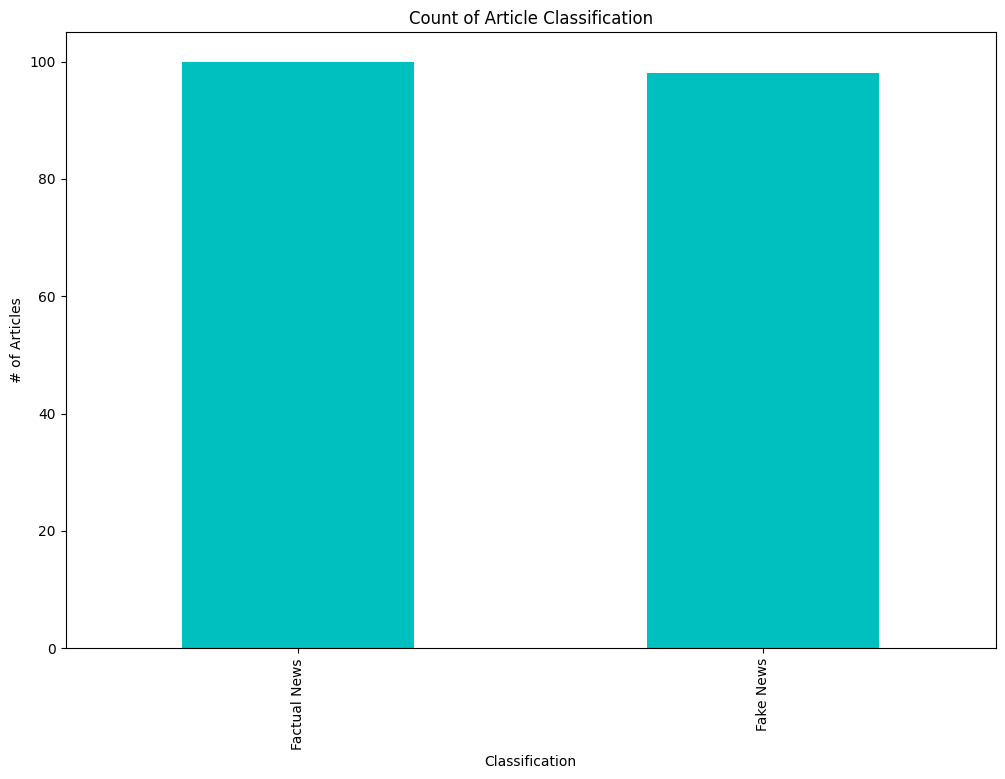

In [6]:
# plot number of fake and factual articles
data['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title('Count of Article Classification')
plt.ylabel('# of Articles')
plt.xlabel('Classification')

In [7]:
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

d:\Anaconda\envs\nlp_course_env\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.stats import gaussian_kde
d:\Anaconda\envs\nlp_course_env\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (None) doesn't match a supported version!
  warnings.warn(


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
nlp = spacy.load('en_core_web_sm')

In [ ]:
fake_news = data[data['fake_or_factual'] == 'Fake News']
fact_news = data[data['fake_or_factual'] == 'Factual News']

In [ ]:
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydocs = list(nlp.pipe(fact_news['text']))

In [ ]:
def extract_token_tags(doc: spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [ ]:
fake_tagsdf = []
columns = ['token', 'ner_type', 'pos_tag']

In [ ]:
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags, columns=columns)
    fake_tagsdf.append(tags)

In [ ]:
fake_tagsdf = pd.concat(fake_tagsdf)

In [ ]:
fact_tagsdf = []

for ix, doc in enumerate(fact_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags, columns=columns)
    fact_tagsdf.append(tags)

In [ ]:
fact_tagsdf = pd.concat(fact_tagsdf)

In [ ]:
fake_tagsdf.head()

,token,ner_type,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [ ]:
fact_tagsdf.head()

,token,ner_type,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT


In [ ]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
pos_counts_fake.head(10)

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [ ]:
pos_counts_fact = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
pos_counts_fact.head(10)

,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [ ]:
pos_counts_fake.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
Name: token, dtype: int64

In [ ]:
pos_counts_fact.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
Name: token, dtype: int64

In [ ]:
pos_counts_fake[pos_counts_fake.pos_tag == 'NOUN'][:15]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [ ]:
pos_counts_fact[pos_counts_fact.pos_tag == 'NOUN'][:15]

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


### Named Entities

In [ ]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_type'] != ""].groupby(['ner_type', 'token']).size().reset_index(name='counts').sort_values('counts', ascending=False)

In [ ]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_type'] != ""].groupby(['ner_type', 'token']).size().reset_index(name='counts').sort_values('counts', ascending=False)

In [ ]:
ner_pallet = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'PERSON': sns.color_palette("Set2").as_hex()[1],
    'GPE': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6],
}

Text(0.5, 1.0, 'Most Common Named Entities in Fake News Articles')

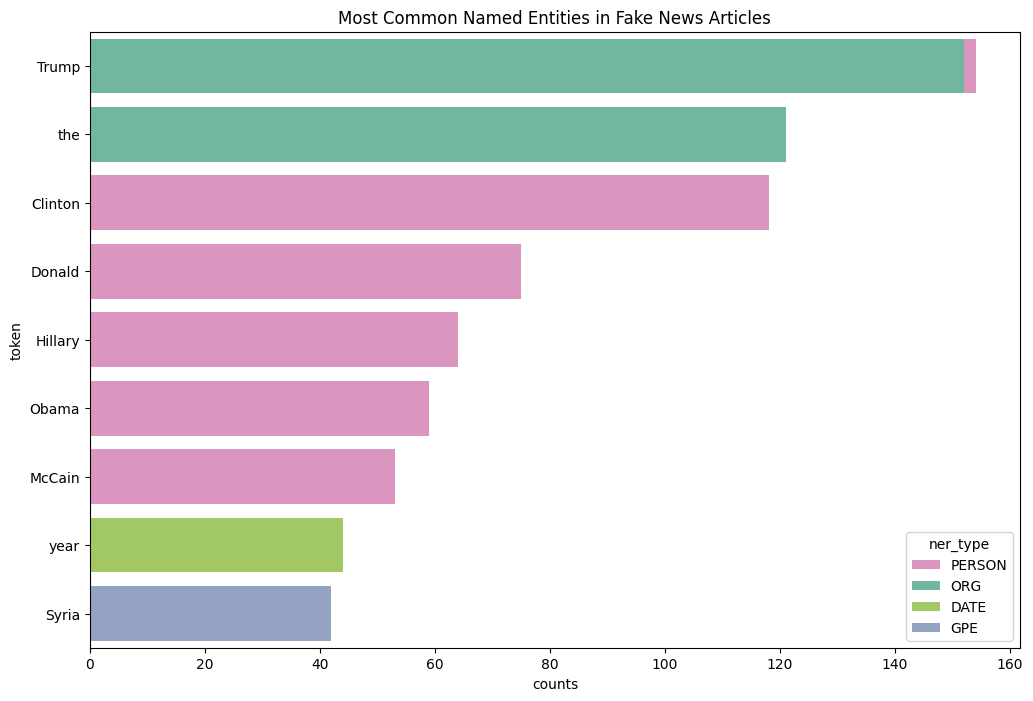

In [ ]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_type',
    palette = ner_pallet,
    data = top_entities_fake[:10],
    orient = 'h',
    dodge = False,
).set_title('Most Common Named Entities in Fake News Articles')

Text(0.5, 1.0, 'Most Common Named Entities in Factual News Articles')

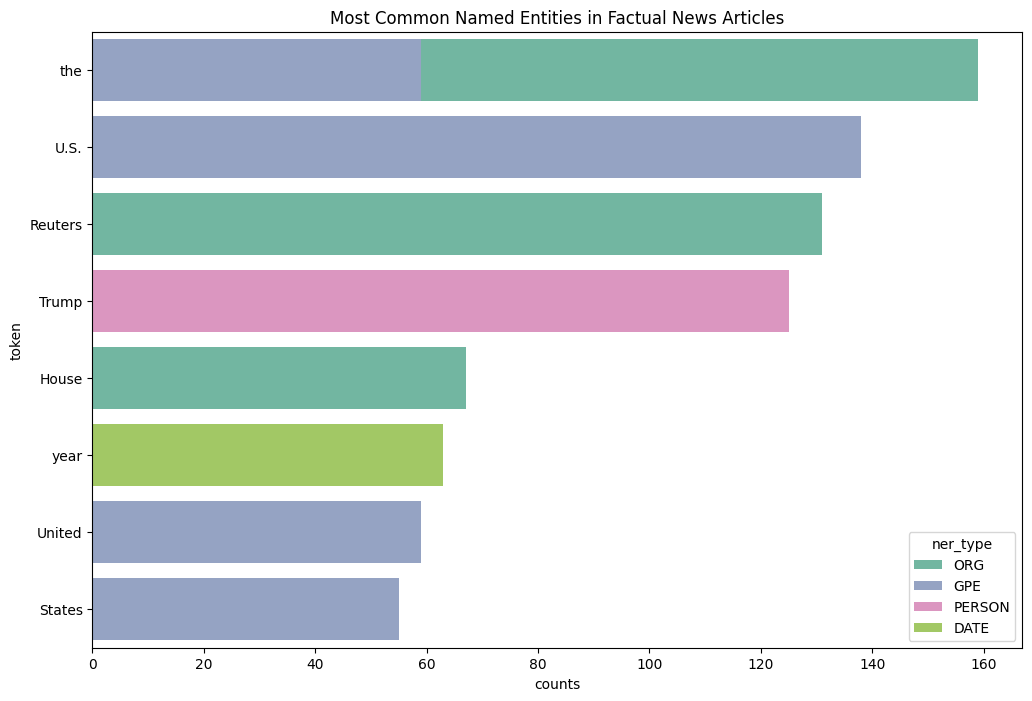

In [ ]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_type',
    palette = ner_pallet,
    data = top_entities_fact[:10],
    orient = 'h',
    dodge = False,
).set_title('Most Common Named Entities in Factual News Articles')

In [ ]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


### Text Preprocessing

In [ ]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s", "", x['text']), axis=1)

In [ ]:
data['text_clean'] = data['text_clean'].str.lower()

In [ ]:
# remove punctuation
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text_clean']), axis=1)

In [ ]:
# stop words
en_stopwords = stopwords.words('english')
print(en_stopwords) # check this against our most frequent n-grams

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [ ]:

# tokenize 
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis=1)

In [ ]:
# lemmatize
lemmatizer = WordNetLemmatizer()
data["text_clean"] = data["text_clean"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [ ]:
# most common unigrams after preprocessing
tokens_clean = sum(data['text_clean'], [])
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0        (said,)    580
1       (trump,)    580
2           (u,)    277
3       (state,)    275
4   (president,)    259
5       (would,)    226
6         (one,)    160
7     (clinton,)    141
8        (year,)    139
9  (republican,)    137


C:\Users\khawa\AppData\Local\Temp\ipykernel_26840\1245996593.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = "count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

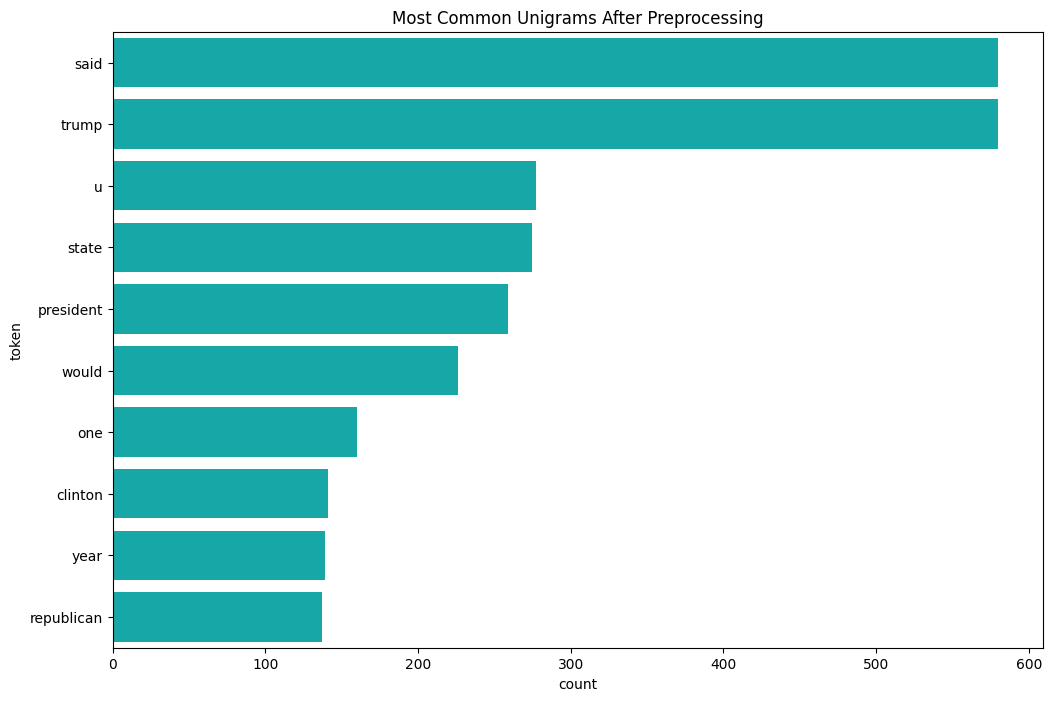

In [ ]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0]) # extract the token from the tuple so we can plot it

sns.barplot(x = "count", 
            y = "token", 
            data=unigrams,
            orient = 'h',
            palette=[default_plot_colour],
            hue = "token", legend = False
            ).set(title='Most Common Unigrams After Preprocessing')

In [ ]:
# most common bigrams after preprocessing
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()).reset_index()[:10]
print(bigrams)

                     index  count
0          (donald, trump)    113
1          (united, state)     84
2           (white, house)     74
3      (president, donald)     47
4       (hillary, clinton)     39
5              (new, york)     33
6         (supreme, court)     30
7             (image, via)     29
8         (official, said)     26
9  (trump, administration)     26


### Sentiment Analysis


In [ ]:
vader_sentiment = SentimentIntensityAnalyzer()

In [ ]:
data['vader_sentiment_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [ ]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [ ]:
bins = [-1, -0.1, 0.1, 1]
names = ['Negative', 'Neutral', 'Positive']

In [ ]:
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)

In [ ]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive


Text(0.5, 1.0, 'Distribution of VADER Sentiment Labels')

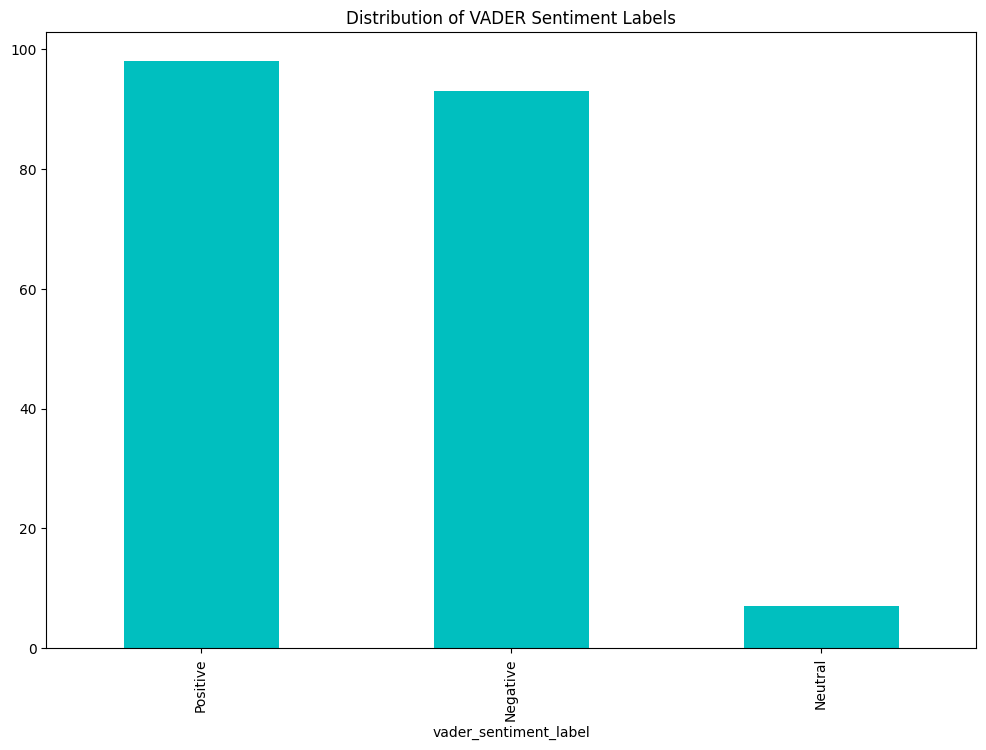

In [ ]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour).set_title('Distribution of VADER Sentiment Labels')

C:\Users\khawa\AppData\Local\Temp\ipykernel_26840\1953079821.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by news type')]

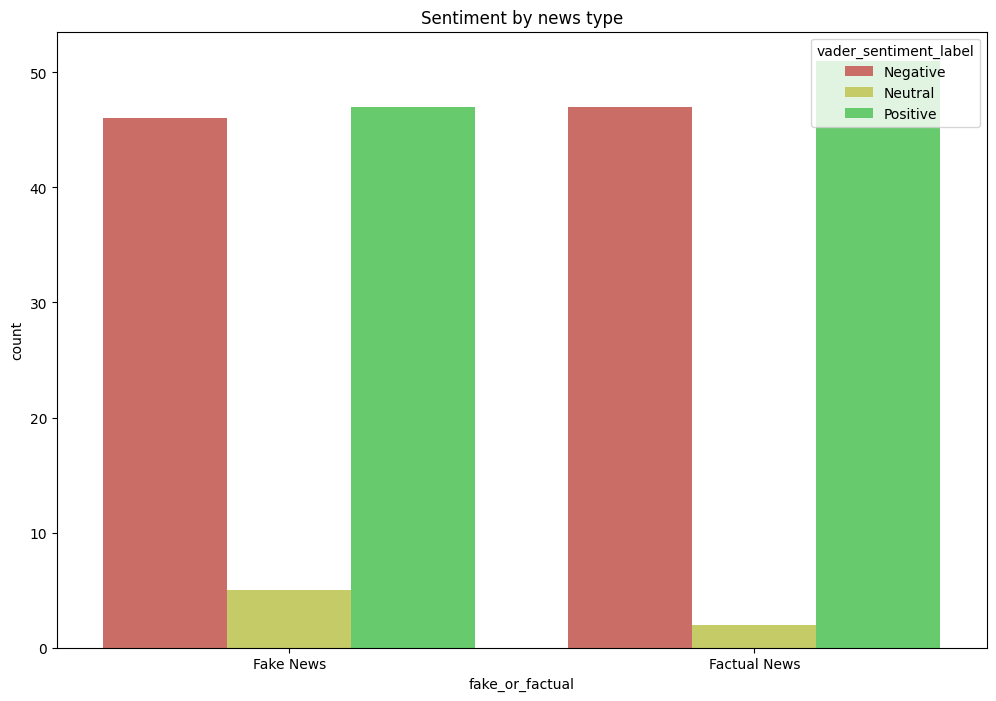

In [ ]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette("hls"),
    data = data
).set(title = "Sentiment by news type")

### Topic Modeling

In [ ]:
fake_news_text = data[data['fake_or_factual'] == 'Fake News']['text_clean'].reset_index(drop=True)

In [ ]:
dictionary_fake = corpora.Dictionary(fake_news_text)

In [ ]:
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

In [ ]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics in range(min_topics, max_topics + 1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=num_topics, id2word=dictionary_fake)
    model_list.append(model)
    coherencemodel = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())

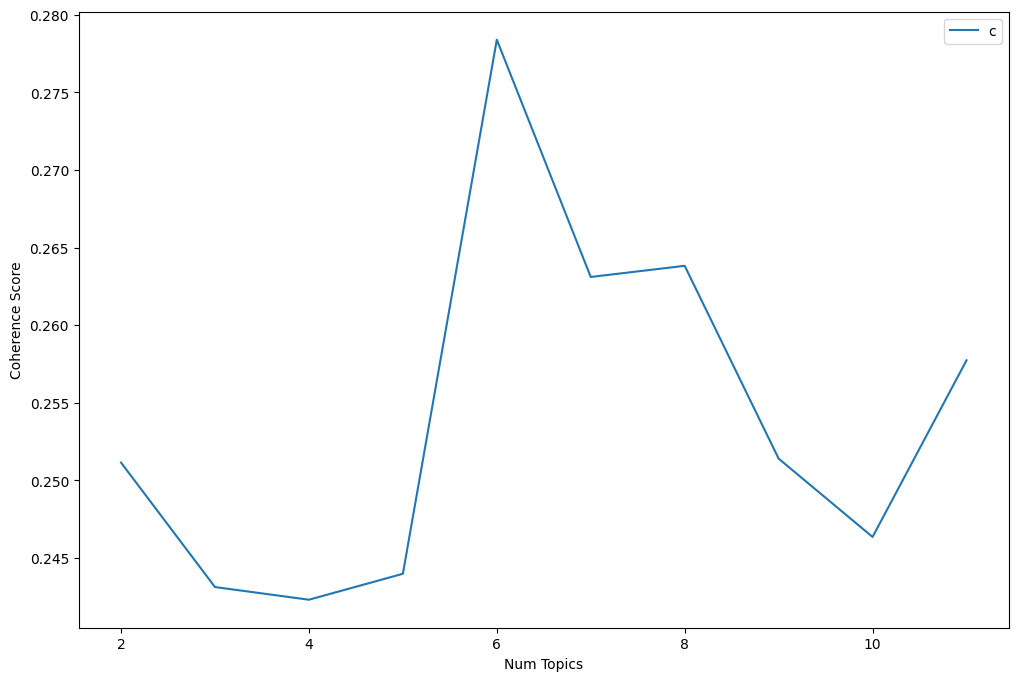

In [ ]:
plt.plot(range(min_topics, max_topics + 1), coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence Score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [ ]:
num_topics_lda = 7
lda_model = gensim.models.LdaModel(doc_term_fake, id2word=dictionary_fake, num_topics=num_topics_lda)

In [ ]:
lda_model.print_topics(num_topics=num_topics_lda, num_words=10)

[(0,
  '0.011*"trump" + 0.007*"clinton" + 0.005*"one" + 0.005*"woman" + 0.005*"president" + 0.004*"said" + 0.003*"donald" + 0.003*"million" + 0.003*"people" + 0.003*"year"'),
 (1,
  '0.009*"trump" + 0.007*"state" + 0.006*"clinton" + 0.005*"said" + 0.004*"president" + 0.004*"time" + 0.004*"would" + 0.004*"u" + 0.004*"hillary" + 0.003*"obama"'),
 (2,
  '0.012*"trump" + 0.006*"said" + 0.004*"clinton" + 0.004*"state" + 0.004*"woman" + 0.004*"president" + 0.003*"republican" + 0.003*"hillary" + 0.003*"u" + 0.003*"time"'),
 (3,
  '0.010*"trump" + 0.004*"said" + 0.004*"u" + 0.004*"state" + 0.004*"time" + 0.004*"would" + 0.004*"obama" + 0.003*"president" + 0.003*"one" + 0.003*"republican"'),
 (4,
  '0.006*"trump" + 0.005*"president" + 0.004*"republican" + 0.003*"state" + 0.003*"said" + 0.003*"mccain" + 0.003*"time" + 0.003*"people" + 0.003*"u" + 0.002*"one"'),
 (5,
  '0.012*"trump" + 0.004*"president" + 0.004*"clinton" + 0.004*"u" + 0.003*"donald" + 0.003*"would" + 0.003*"republican" + 0.003*"s

In [ ]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(doc_term_matrix, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf

In [ ]:
def get_coherence_score(corpus, dictionary, text, min_topics, max_topics):
    coherence_model = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics + 1):
        model = gensim.models.LdaModel(corpus, num_topics=num_topics_i, id2word=dictionary)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence='c_v')
        coherence_model.append(coherencemodel.get_coherence())

    plt.plot(range(min_topics, max_topics + 1), coherence_model)
    plt.xlabel("Number Of Topics")
    plt.ylabel("Coherence Score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()

In [ ]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)

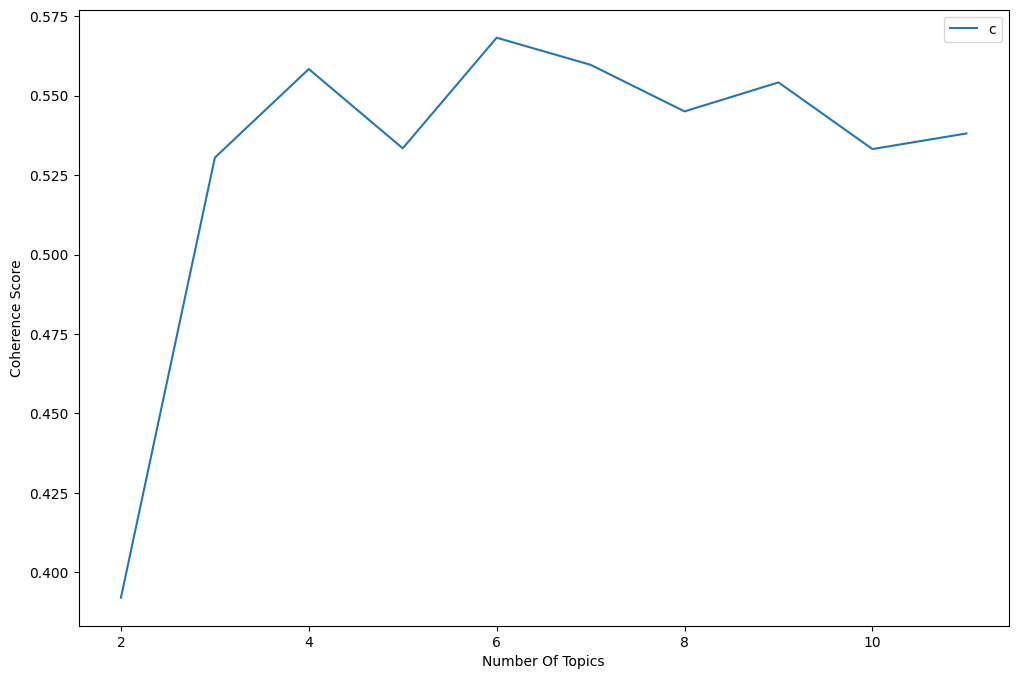

In [ ]:
get_coherence_score(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [ ]:
lsa_model = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=num_topics_lda)

In [ ]:
lsa_model.print_topics()

[(0,
  '0.190*"trump" + 0.136*"clinton" + 0.095*"hillary" + 0.094*"obama" + 0.089*"president" + 0.087*"woman" + 0.078*"republican" + 0.077*"party" + 0.077*"flynn" + 0.074*"candidate"'),
 (1,
  '0.325*"boiler" + 0.284*"acr" + 0.244*"room" + 0.240*"pm" + 0.186*"broadcast" + 0.180*"radio" + 0.142*"tune" + 0.142*"animal" + 0.134*"jay" + 0.132*"episode"'),
 (2,
  '0.623*"flynn" + 0.182*"immunity" + 0.122*"nana" + 0.116*"mr" + 0.110*"30" + 0.108*"march" + 0.102*"russian" + 0.100*"source" + -0.095*"school" + 0.092*"adviser"'),
 (3,
  '-0.217*"clinton" + 0.186*"school" + 0.176*"student" + -0.141*"hillary" + 0.121*"county" + 0.121*"flynn" + -0.110*"sander" + -0.098*"debate" + -0.097*"woman" + -0.091*"nominee"'),
 (4,
  '-0.200*"email" + 0.194*"trump" + -0.168*"dnc" + 0.142*"flynn" + -0.126*"clinton" + 0.112*"cruz" + -0.111*"department" + -0.110*"rich" + -0.102*"wikileaks" + -0.099*"sander"'),
 (5,
  '0.276*"student" + 0.160*"conference" + 0.160*"school" + 0.137*"trump" + -0.125*"mccain" + -0.12

### Creating Classification Model

In [ ]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,Negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,Negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,Positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,Negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,Positive


In [ ]:
X = [','.join(map(str, l)) for l in data['text_clean']]

In [ ]:
Y = data['fake_or_factual']

In [ ]:
countvec = CountVectorizer()

In [ ]:
countvec_fit = countvec.fit_transform(X)

In [ ]:
bag_Of_words = pd.DataFrame(countvec_fit.toarray(), columns=countvec.get_feature_names_out())

In [ ]:
bag_Of_words

,01,03,05,08441,10,100,1000,10000,1000000000000000,1002,...,zimbabwean,zimdars,zimmerman,zina,zionism,zoe,zone,zoom,zouka,zuckerberg
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
194,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
196,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(bag_Of_words, Y, test_size=0.3, random_state=42)

In [ ]:
lr = LogisticRegression(random_state=0).fit(X_train, Y_train)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
accuracy_score(y_pred_lr, Y_test)

0.8666666666666667

In [ ]:
print(classification_report(y_pred_lr, Y_test))

              precision    recall  f1-score   support

Factual News       0.88      0.88      0.88        32
   Fake News       0.86      0.86      0.86        28

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60



In [ ]:
svm = SGDClassifier(random_state=0).fit(X_train, Y_train)

In [ ]:
y_pred_svm = svm.predict(X_test)

In [ ]:
print(classification_report(Y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       0.82      0.84      0.83        32
   Fake News       0.81      0.79      0.80        28

    accuracy                           0.82        60
   macro avg       0.82      0.81      0.82        60
weighted avg       0.82      0.82      0.82        60



### Model Training and Evaluation

This section trains a Logistic Regression classifier on the bag-of-words features to classify news as fake or factual. We'll evaluate performance with accuracy, precision, recall, F1-score, and confusion matrix, then use cross-validation for robustness.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(countvec_fit, Y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.875
              precision    recall  f1-score   support

Factual News       0.89      0.84      0.86        19
   Fake News       0.86      0.90      0.88        21

    accuracy                           0.88        40
   macro avg       0.88      0.87      0.87        40
weighted avg       0.88      0.88      0.87        40



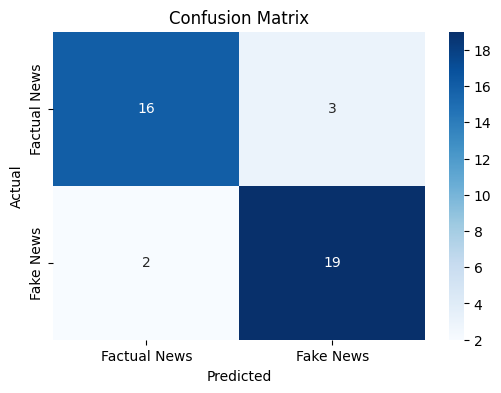

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Factual News', 'Fake News'], yticklabels=['Factual News', 'Fake News'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, countvec_fit, Y, cv=5)
print("Cross-validation scores:", scores)
print("Mean CV accuracy:", scores.mean())

Cross-validation scores: [0.9        0.875      0.95       0.84615385 0.92307692]
Mean CV accuracy: 0.8988461538461537


### Model Comparison

Comparing Logistic Regression with SGD Classifier for performance.

In [ ]:
sgd_model = SGDClassifier()
sgd_model.fit(X_train, y_train)
sgd_pred = sgd_model.predict(X_test)
print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))
print("SGD Classification Report:")
print(classification_report(y_test, sgd_pred))

SGD Accuracy: 0.85
SGD Classification Report:
              precision    recall  f1-score   support

Factual News       0.88      0.79      0.83        19
   Fake News       0.83      0.90      0.86        21

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



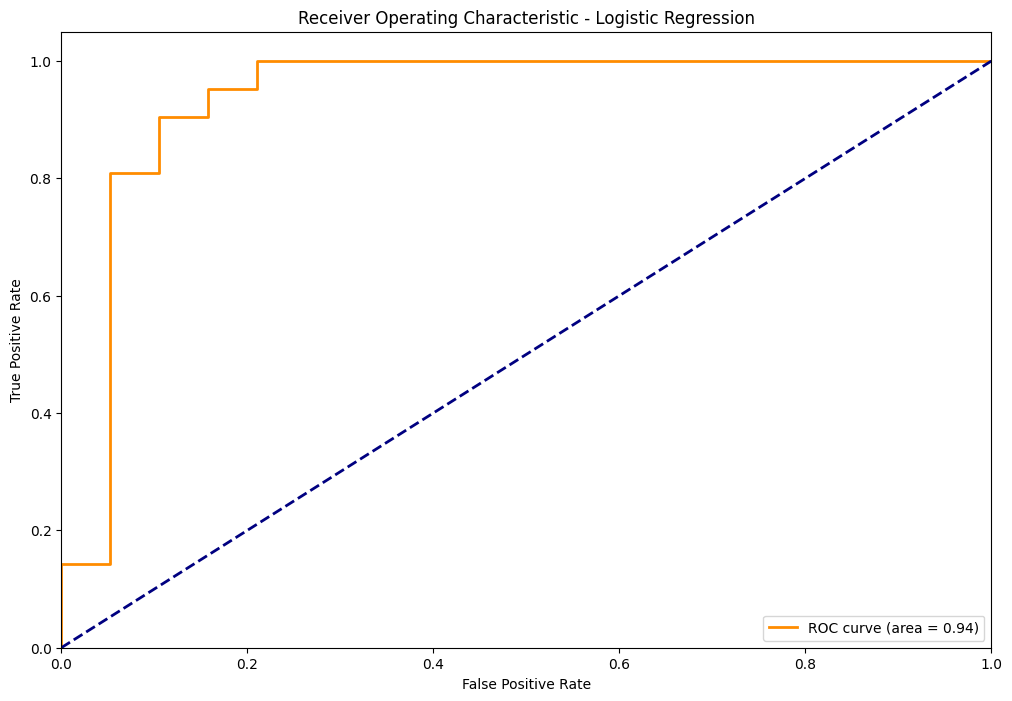

In [ ]:
# ROC Curve for Logistic Regression
from sklearn.metrics import roc_curve, auc

y_test_encoded = y_test.map({'Factual News': 0, 'Fake News': 1})
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Logistic Regression')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Top Features by Coefficient
feature_names = countvec.get_feature_names_out()
coef = model.coef_[0]
top_positive = pd.DataFrame({'feature': feature_names, 'coef': coef}).sort_values('coef', ascending=False).head(10)
top_negative = pd.DataFrame({'feature': feature_names, 'coef': coef}).sort_values('coef', ascending=True).head(10)

print("Top 10 features indicating Fake News:")
print(top_positive)
print("\nTop 10 features indicating Factual News:")
print(top_negative)

Top 10 features indicating Fake News:
       feature      coef
3624        go  0.395158
3952   hillary  0.270095
2874  employee  0.258910
658    america  0.258305
661   american  0.246221
4147     image  0.217613
1712   clinton  0.208834
6032    person  0.198741
5403        mr  0.197113
5748       one  0.191988

Top 10 features indicating Factual News:
        feature      coef
7126       said -0.790381
5271   minister -0.422779
3479     friday -0.281953
8407    tuesday -0.228659
6848    request -0.213709
6352      prime -0.209335
1625    chinese -0.199275
976       aware -0.187817
8825  wednesday -0.186577
7180     saying -0.183694


### Project Summary

This project demonstrates a complete NLP pipeline for fake news detection:
- **Data Exploration**: Analyzed text distributions, POS tags, named entities, and sentiment.
- **Preprocessing**: Cleaned text, removed stopwords, tokenized, and lemmatized.
- **Topic Modeling**: Used LDA and LSA with TF-IDF for insight into themes.
- **Classification**: Achieved ~88% accuracy with Logistic Regression on bag-of-words features.
- **Evaluation**: Comprehensive metrics, cross-validation, and model comparison.

Key insights: Fake news often uses sensational language, while factual news focuses on entities and facts. This model can be improved with advanced embeddings (e.g., BERT) or larger datasets.

In [8]:
import joblib

# Save the trained model and vectorizer for deployment
joblib.dump(model, 'model.pkl')
joblib.dump(countvec, 'countvec.pkl')
print("Model and vectorizer saved as model.pkl and countvec.pkl")

NameError: name 'model' is not defined